## Poisson equation
This notebook contains the code for solving the following stochastic Poisson equation using the PINN-PC framework

### Equation
$-\frac{d^2 u}{dx^2} = f(x,w)$  
$u(-1) = u(1) = 0$  
$f(x,w) \sim GP(f_0(x), k(x,x'))$  
$f_0(x) = 10 \sin(\pi x)$  
$k(x,x') = \sigma^2 \exp\left(-\frac{(x-x')^2}{l^2}\right)$

Where:  
$\sigma = 1$ and $l = 0.5$

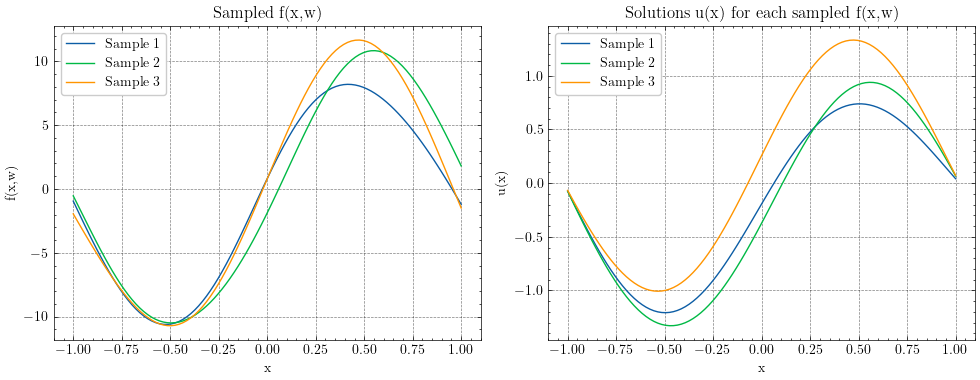

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

#nice plots, optional
import scienceplots
plt.style.use(['science', 'grid'])

# Define parameters
sigma = 1
l = 0.5
n_points = 100
x = np.linspace(-1, 1, n_points)
dx = x[1] - x[0]

# Define the mean function and the kernel
f0 = lambda x: 10 * np.sin(np.pi * x)

def kernel(x, x_prime, sigma=sigma, l=l):
    return sigma**2 * np.exp(-((x-x_prime)**2) / l**2)

# Sample from the GP
def sample_GP(x, n_samples=1):
    mu = f0(x)
    K = np.array([[kernel(xi, xj) for xj in x] for xi in x])
    return np.random.multivariate_normal(mu, K, n_samples)

# Finite differences using scipy's sparse matrix to solve the Poisson equation
def solve_poisson(f, dx, u_left=0, u_right=0):
    N = len(f)
    diagonals = [-2 * np.ones(N), np.ones(N - 1), np.ones(N - 1)]
    A = diags(diagonals, [0, 1, -1], format="csr")
    A = A / dx**2

    # Set boundary conditions
    f[0] += u_left / dx**2
    f[-1] += u_right / dx**2

    u = spsolve(A, -f)
    return u

# Sample f(x,w) and solve the Poisson equation for each sample
n_samples = 3
f_samples = sample_GP(x, n_samples)
u_solution = np.array([solve_poisson(f_sample, dx) for f_sample in f_samples])

plt.figure(figsize=(10, 4))

# Left subplot for f(x,w)
plt.subplot(1, 2, 1)
for i in range(n_samples):
    plt.plot(x, f_samples[i], label=f"Sample {i+1}")
plt.title("Sampled f(x,w)")
plt.xlabel('x')
plt.ylabel('f(x,w)')
plt.legend()

# Right subplot for u(x)
plt.subplot(1, 2, 2)
for i in range(n_samples):
    plt.plot(x, u_solution[i], label=f"Sample {i+1}")
plt.title("Solutions u(x) for each sampled f(x,w)")
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()

plt.tight_layout()
plt.show()

100%|██████████| 10000/10000 [00:07<00:00, 1279.10it/s]


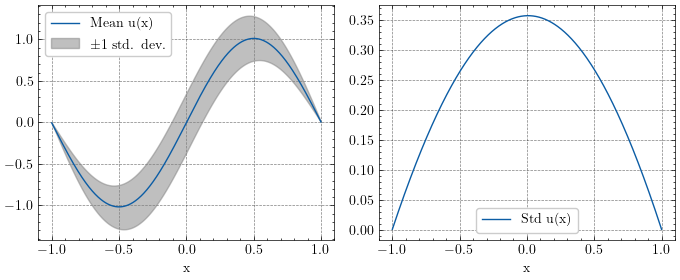

In [ ]:
# Monte Carlo approximation of the mean and standard deviation of the solution
from tqdm import tqdm

n_points = 1000
x = np.linspace(-1, 1, n_points)
dx = x[1] - x[0]

n_samples = 1000
f_samples = sample_GP(x, n_samples) # Matrix of shape (n_samples, n_points)
u_solution = np.array([solve_poisson(f_sample, dx) for f_sample in tqdm(f_samples)]) # Matrix of shape (n_samples, n_points)

# Calculate the mean and standard deviation along the sample axis
u_mean = u_solution.mean(axis=0)
u_std = u_solution.std(axis=0)

# Plot the mean and standard deviation side by side
fig = plt.figure(figsize=(7, 3))

# Left subplot for mean of u(x)
plt.subplot(1, 2, 1)
plt.plot(x, u_mean, label="Mean u(x)")
plt.fill_between(x, u_mean - u_std, u_mean + u_std, color='gray', alpha=0.5, label="±1 std. dev.")
# plt.title("Mean Solution u(x)")
plt.xlabel('x')
plt.legend()

# Right subplot for standard deviation of u(x)
plt.subplot(1, 2, 2)
plt.plot(x, u_std, label="Std u(x)")
# plt.title("Standard Deviation of Solutions u(x)")
plt.xlabel('x')
plt.legend()

plt.tight_layout()
plt.show()
# fig.savefig('figures/MonteCarlo_mean_std.pdf', bbox_inches='tight')

<>:32: SyntaxWarning: invalid escape sequence '\%'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\%'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7301/3700772992.py:32: SyntaxWarning: invalid escape sequence '\%'
  plt.ylabel('Explained Variance (\%)')
/tmp/ipykernel_7301/3700772992.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(x, eigenvectors[:, i], label="$\lambda_{}$ = {:.2f}".format(i+1, eigenvalues[i]))


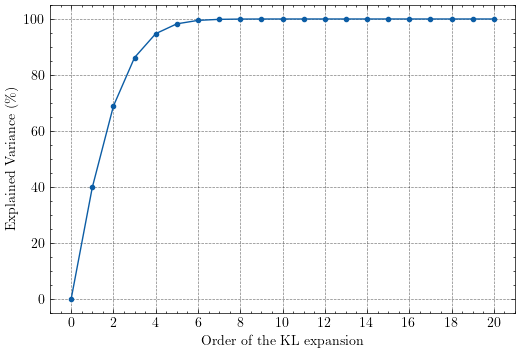

99.0% of variance explained with 6 modes


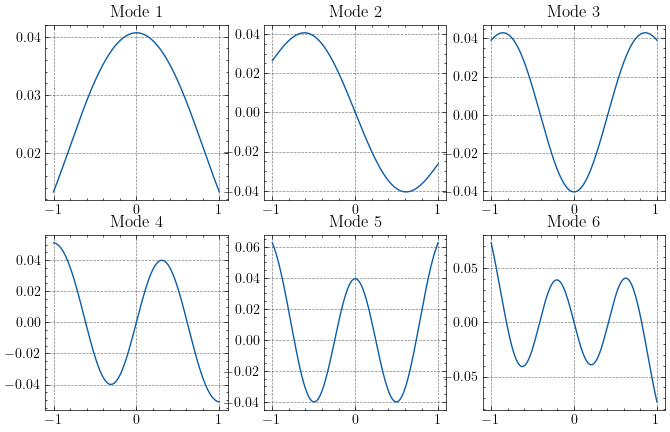

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Define the GP kernel
def kernel(x, x_prime, sigma=sigma, l=l):
    return sigma**2 * np.exp(-((x-x_prime)**2) / l**2)


def KL_expansion(x, kernel,truncation_order):
    """Compute the KL expansion of the GP prior defined by the kernel function."""
    K = np.array([[kernel(xi, xj) for xj in x] for xi in x])
    eigenvalues, eigenvectors = eigh(K)#,driver='evx')
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    for i in range(truncation_order):
        if eigenvectors[0, i] < 0:
            eigenvectors[:, i] *= -1 # Eigenvectors are defined up to a scalar factor
    return eigenvalues[:truncation_order], eigenvectors[:, :truncation_order]

eigenvalues, eigenvectors = KL_expansion(x, kernel, truncation_order=20)

# Compute the cumulative explained variance
explained_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues) 

# Plot explained variance
fig = plt.figure(figsize=(6, 4))
n_orders = 20
plt.plot(np.arange(0, n_orders + 1), [0] + list(explained_variance[:n_orders] * 100), marker='.')
plt.xlabel('Order of the KL expansion')
plt.ylabel('Explained Variance (\%)')
# plt.title('Explained Variance vs. Order of KL Expansion')
plt.xticks(np.arange(0, n_orders + 1, 2))
plt.show()
# fig.savefig('figures/KL_explained_variance.pdf', format='pdf')
    
# Propose truncation order based on a threshold
threshold = 0.99  # Example threshold for 99% explained variance
truncation_order = np.argmax(explained_variance >= threshold) + 1
print(f"{threshold*100}% of variance explained with {truncation_order} modes")

# Plot the first 6 modes
fig, axs = plt.subplots(2, int(truncation_order/2), figsize=(8, 5))
for i, ax in enumerate(axs.flat):
    ax.plot(x, eigenvectors[:, i], label="$\lambda_{}$ = {:.2f}".format(i+1, eigenvalues[i]))
    ax.set_title(f"Mode {i+1}")
    # ax.legend()
# fig.savefig('figures/KL_modes.pdf', format='pdf')


In [13]:
import time
#approximating PCE modes by Monte Carlo
def f_from_xi(xi, x_train, eigenvalues, eigenvectors, f0):
    """Compute the function f(x) from the random variables xi."""
    f_stoch = np.sqrt(eigenvalues) * xi @ eigenvectors.T
    f = f0(x_train) + f_stoch
    return f

t_start = time.time()
seed = 42
n_xi_samples = int(1e4) #number of samples
n_x_points = 1000 #spatial discretization
truncation_order = 6
modes_function = np.zeros((truncation_order, n_x_points))

x_test = np.linspace(-1, 1, n_x_points)
dx = x_test[1] - x_test[0]
eigenvalues, eigenvectors = KL_expansion(x_test, kernel, truncation_order)

np.random.seed(seed) # Set seed for reproducibility
xi_test = np.random.randn(n_xi_samples, truncation_order)

print("f samples :")
f_samples = [f_from_xi(xi, x_test, eigenvalues, eigenvectors, f0) for xi in tqdm(xi_test)]
print("u resolution :")
u_solution = np.array([solve_poisson(f_sample, dx) for f_sample in tqdm(f_samples)]) # Matrix of shape (n_samples, n_points)
u_mean = u_solution.mean(axis=0) # = f0(x_test)/np.pi**2 
u_stoch = u_solution - u_mean
modes_function = np.zeros((truncation_order, len(x_test)))
for mode in range(0,truncation_order):
    xi_mode = xi_test[:,mode]
    modes_function[mode,:] = np.sum(xi_test[:,mode].reshape(-1,1) * u_stoch, axis=0)/n_xi_samples

print(f"Time taken: {time.time() - t_start:.2f} s")

f samples :


100%|██████████| 10000/10000 [00:00<00:00, 39666.01it/s]


u resolution :


100%|██████████| 10000/10000 [00:07<00:00, 1271.12it/s]


Time taken: 12.72 s


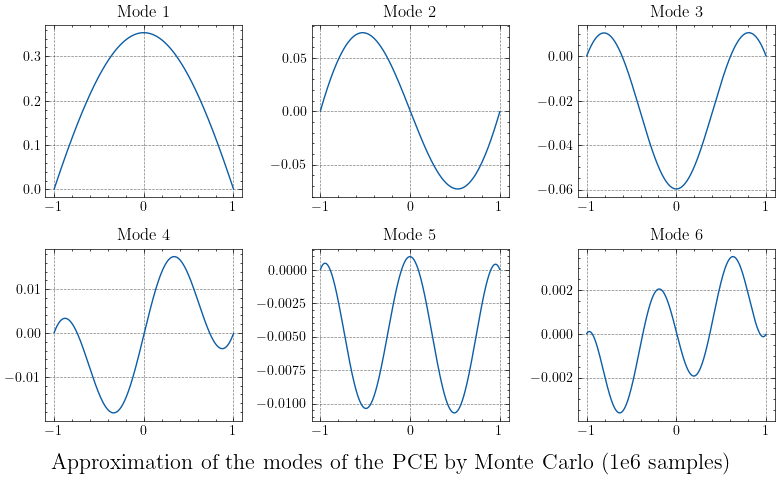

In [6]:
#save the reference solution
save = False
if save:
    np.save(f'MonteCarlo_PCE_modes_1e{np.log10(n_xi_samples)}.npy', modes_function)

# MonteCarlo_PCE_modes = modes_function
MonteCarlo_PCE_modes = np.load('data/MonteCarlo_PCE_modes_1e6.0.npy')

fig, axs = plt.subplots(2, int(len(MonteCarlo_PCE_modes)/2), figsize=(8, 5))
for i, mode in enumerate(MonteCarlo_PCE_modes):
    i_row = i // (len(MonteCarlo_PCE_modes) // 2)
    i_col = i % (len(MonteCarlo_PCE_modes) // 2)
    axs[i_row, i_col].plot(x_test, mode)
    axs[i_row, i_col].set_title(f"Mode {i + 1}")
plt.suptitle(f"Approximation of the modes of the PCE by Monte Carlo (1e6 samples)", y=0, fontsize=16)
plt.tight_layout()
plt.show()
# fig.savefig('figures/MonteCarlo_PCE_modes.pdf', format='pdf')

Monte Carlo converges in $O(N^{-1/2})$ where $N$ is the number of samples.
To be able to approximate modes 6 (order of magnitude $10^{-3}$) we need at least $10^6$ samples

## Implementation of the PINN-PC framework with DeepXDE

In [120]:
# The code has been tested with both JAX and PyTorch backends. It should work with TensorFlow/Paddle as well but has not been tested.
# JAX is recommended for higher computational performance (x10-x20 faster than PyTorch in our implementation).
import deepxde as dde
import jax
import jax.numpy as jnp

truncation_order = 6
n_sensors = 13
    
bc_type = "hard" # Choose between "hard" and "soft" boundary conditions
n_x_points = 100
n_xi_samples = 100000
n_xi_batch = 10000
n_sensors = 13
sensors_indices = np.linspace(0, n_x_points - 1, n_sensors, dtype=int)

xi_train = np.random.randn(n_xi_samples, truncation_order) # samples of the random variables
x_train = np.linspace(-1, 1, n_x_points) # spatial discretization used in the KL expansion

eigenvalues, eigenvectors = KL_expansion(x_train, kernel, truncation_order)
f_samples = np.array([f_from_xi(xi, x_train, eigenvalues, eigenvectors, f0) for xi in xi_train])

x_sensor = x_train[sensors_indices].reshape(-1,1) #collocation points to train the pde (where f is known)
f_sensor = f_samples[:,sensors_indices].T #value of forcing term at the collocation points

dtype = dde.backend.data_type_dict["float32"]
xi_train = dde.backend.as_tensor(xi_train, dtype=dtype)
f_sensor = dde.backend.as_tensor(f_sensor, dtype=dtype)

def transform_coords(x):
    """
    For SPINN, if the input x is provided as a list of 1D arrays (e.g., [X_coords, Y_coords]),
    this function creates a 2D meshgrid and stacks the results into a 2D coordinate array.
    """
    x_mesh = [x_.ravel() for x_ in jnp.meshgrid(jnp.atleast_1d(x[0].squeeze()), jnp.atleast_1d(x[1].squeeze()), indexing="ij")]
    return dde.backend.stack(x_mesh, axis=-1)

def hessian(y, x, comp=0, i=0, j=0): # distinguish between jax and and other backends
    hessian_val = dde.grad.hessian(y, x, comp, i, j)
    return hessian_val[0] if dde.backend.backend_name == "jax" else hessian_val

def u_xi(x, f, xi):
    output = f([[x, xi]])[0]
    if output[1].ndim == 1:
        output[1] = output[1].reshape(1, -1)
    ones_column = jnp.ones((output[1].shape[0], 1))
    xi_array = jnp.hstack([ones_column, output[1]]).T
    u = jnp.dot(output[0], xi_array)
    return u 

def orthogonality_loss(f_xi):
    """
    Computes the orthogonality loss for output f_xi of shape (n_batch, n_basis_function).
    The loss is the squared Frobenius norm of (G - I), where
    G = (f_xi^T f_xi) / n_batch and I is the identity matrix.
    """
    n_batch = f_xi.shape[0]
    # Compute Gram matrix G: (n_basis_function, n_basis_function)
    G = (f_xi.T @ f_xi) / n_batch
    identity = jnp.eye(G.shape[0])
    loss = jnp.linalg.norm(G - identity)
    return loss

def pde(x, f):

    indices = np.random.permutation(xi_train.shape[0])[:n_xi_batch]
    xi_batch = x[1][indices]
    f_batch = f_sensor[:,indices]
        
    f_x = lambda z: u_xi(z, f[1], xi_batch)

    hess_f = jax.jacfwd(jax.jacfwd(f_x, argnums=0), argnums=0)
    d2u_dx2 = jax.vmap(hess_f)(x[0]).squeeze()

    pde_residual = d2u_dx2 + f_batch

    ortho_residual = orthogonality_loss(f[0][1])

    losses = [pde_residual, ortho_residual]



    if bc_type == "soft":
        if dde.backend.backend_name == "jax":
            f = f[0]
        u_predicted = f[:,:1].flatten() + xi_batch @  f[:,1:].T
        bc_left = u_predicted[:,0]
        bc_right = u_predicted[:,-1]
        losses += [bc_left, bc_right]
    return losses

def hard_bc(x, output):
    # if output[1].ndim == 1:
    #     output[1] = output[1].reshape(1, -1)
    # ones_column = jnp.ones((output[1].shape[0], 1))
    # xi_array = jnp.hstack([ones_column, output[1]]).T
    # u = jnp.dot(output[0], xi_array)
    # return u * (1 + x[0]) * (1 - x[0])
    return (output[0] * (1 + x[0]) * (1 - x[0]), output[1]) #-output[1].mean(axis=0))/output[1].std(axis=0)) # mean and std of the output

In [121]:
# geom = dde.geometry.Interval(-1, 1)
geom = dde.geometry.ListPointCloud([x_sensor, xi_train])

data = dde.data.PDE(geom, pde, bcs=[], num_domain=10, is_SPINN=True, num_test=10)
rank = 1#truncation_order
x_layer_size = [1] + [[4,32]]*3 + [[1,rank]]
xi_layer_size = [truncation_order,8,8,rank]
activation = "tanh"
initializer = "Glorot uniform"
regularization = ["l2", 1e-5]
xi_activation = "tanh" 
x_net = dde.nn.PFNN(x_layer_size, activation, initializer, regularization)
xi_net = dde.nn.FNN(xi_layer_size, xi_activation, initializer, regularization, True)
net = dde.nn.MixNN(networks=[x_net, xi_net])
if bc_type == "hard":
    net.apply_output_transform(hard_bc)
    
model = dde.Model(data, net)
model.compile("adam", lr=1e-3,loss_weights=[1,1])

Compiling model...
'compile' took 0.457760 s



In [117]:
from jax.flatten_util import ravel_pytree
import jax

X_input = [[x_sensor, xi_train]]
    
def loss_function(params,comp=0,inputs=X_input):
    return model.outputs_losses_train(params, inputs, None)[1][comp]

n_loss = len(model.loss_weights)

def calc_loss_weights(model):
    loss_grads = [1]*n_loss

    for i in range(n_loss):
        grad_fn = jax.grad(lambda params,comp=i: loss_function(params,comp))
        grads = grad_fn(model.params)[0]
        flattened_grad = ravel_pytree(list(grads.values())[0])[0]
        loss_grads[i] = jnp.linalg.norm(flattened_grad)

    loss_grads = jnp.array(loss_grads)
    loss_weights_grads = jnp.sum(loss_grads)/loss_grads # Caution: ad-hoc sqrt
    return loss_weights_grads, loss_grads

loss_weights_grads, loss_grads = calc_loss_weights(model)
new_loss_weights = [w * g for w, g in zip(model.loss_weights, loss_weights_grads)]
model.compile("adam", lr=0.001,# metrics=[u_mean_metric],
              loss_weights=new_loss_weights)

Compiling model...
'compile' took 0.031561 s



In [127]:
model.train(iterations=5000, display_every=1000)

Training model...

Step      Train loss              Test loss               Test metric
5000      [6.23e-01, 3.34e-07]    [6.20e-01, 3.34e-07]    []  


6000      [6.23e-01, 1.28e-06]    [6.20e-01, 1.28e-06]    []  
7000      [nan, nan]              [nan, nan]              []  

Best model at step 6000:
  train loss: 6.23e-01
  test loss: 6.20e-01
  test metric: []

'train' took 3.461853 s



(<deepxde.model.LossHistory at 0x7fc470b48f80>,
 <deepxde.model.TrainState at 0x7fc472634740>)

In [123]:
n_xi_plot = 100000
xi_plot = np.random.randn(n_xi_plot, truncation_order)
x_plot = np.linspace(-1, 1, n_x_points).reshape(-1, 1)
net_xi = model.net.apply(model.net.params, [x_plot, xi_plot])[1]
# net_xi = np.hstack((np.ones((net_xi.shape[0], 1)), net_xi))

n_batch = net_xi.shape[0]
# Compute Gram matrix G: (n_basis_function, n_basis_function)
G = (net_xi.T @ net_xi) / n_batch
identity = jnp.eye(G.shape[0])
loss = jnp.linalg.norm(G - identity)

print(loss)
print("Gram Matrix (G):")
np.set_printoptions(precision=3, suppress=True)
print(G)

# mode_toplot = 2
# plt.figure(figsize=(10, 4))
# np.std(net_xi, axis=0)
# plt.hist(net_xi[:,mode_toplot], bins=100)
# plt.title("Distribution of first mode")
# plt.show()

# print table of mean and std of the modes
mean = np.mean(net_xi, axis=0)
std = np.std(net_xi, axis=0)
print("Mean of the modes:")
for i in range(len(mean)):
    print(f"Mode {i}: {mean[i]:.2f} ± {std[i]:.2f}")

0.0039675236
Gram Matrix (G):
[[0.996]]
Mean of the modes:
Mode 0: -0.00 ± 1.00


Text(0.5, 1.0, 'Standard deviation of u')

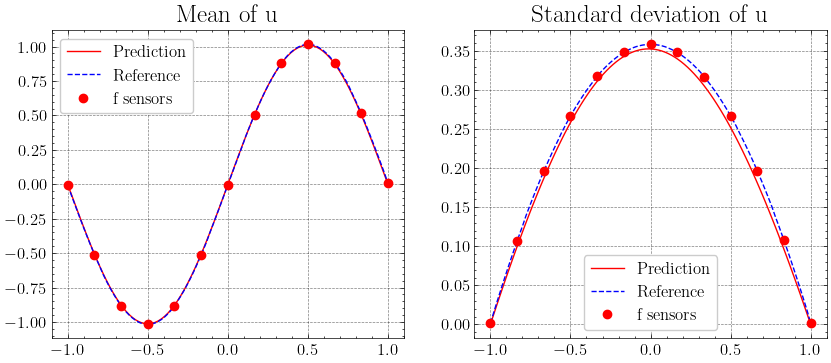

In [124]:
n_x_plot = 100
n_xi_plot = 10000
subsample_ind = [int(i) for i in np.linspace(0,len(u_std)-1,n_x_plot)]
x_sensor = np.linspace(-1, 1, n_sensors)
sensors_indices = np.linspace(0, len(u_std) - 1, n_sensors, dtype=int)
x_plot = np.linspace(-1, 1, n_x_plot).reshape(-1,1)
xi_plot = np.random.randn(n_xi_plot, truncation_order) # samples of the random variables
x_input = [x_plot, xi_plot]

def u_xi(x, f, xi):
    output = f([x, xi])
    if output[1].ndim == 1:
        output[1] = output[1].reshape(1, -1)
    ones_column = jnp.ones((output[1].shape[0], 1))
    xi_array = jnp.hstack([ones_column, output[1]]).T
    u = jnp.dot(output[0], xi_array)
    return u 

u_mean_ref = u_mean
u_std_ref = np.sqrt(np.sum(MonteCarlo_PCE_modes**2, axis=0))
# Evaluate the mean_model to get the predicted mean values

y_pred = lambda z: model.net.apply(model.net.params, z)

predicted_u = u_xi(x_plot, y_pred, xi_plot)
# predicted_mean =  model.net.apply(model.net.params,x_input)[0][:,:1] 
predicted_mean = np.mean(predicted_u, axis=1)

coeffs =model.net.apply(model.net.params,x_input)[0][:,1:]

predicted_std = np.std(predicted_u, axis=1)
# predicted_std = np.sqrt(np.sum(coeffs**2, axis=1))

# Plot the comparison
fig, axs = plt.subplots(1,2,figsize=(10, 4))
axs[0].plot(x_plot, predicted_mean, 'r-', label="Prediction")
axs[0].plot(x_plot, u_mean_ref[subsample_ind], 'b--', label="Reference")
axs[0].plot(x_sensor, u_mean_ref[sensors_indices], 'ro', label="f sensors")
axs[0].legend()
axs[0].set_title('Mean of u')

axs[1].plot(x_plot, predicted_std, 'r-', label="Prediction")
axs[1].plot(x_plot, u_std_ref[subsample_ind], 'b--', label="Reference")
axs[1].plot(x_sensor, u_std_ref[sensors_indices], 'ro', label="f sensors")
axs[1].legend()
axs[1].set_title('Standard deviation of u')

# fig.savefig('figures/PINN_NC_mean_std.png', format='png', dpi=300, bbox_inches='tight')

In [125]:
#compare with the reference solution
x_test = np.linspace(-1, 1, 1000)#.reshape(-1, 1)
dx = x[1] - x[0]
dx = x_test[1] - x_test[0]
eigenvalues, eigenvectors = KL_expansion(x_test, kernel, truncation_order)

#on xi_train
u_pred = u_xi(x_test.reshape(-1,1), y_pred, xi_train[:10000,:])
f_samples_train = [f_from_xi(xi, x_test, eigenvalues, eigenvectors, f0) for xi in tqdm(np.array(xi_train[:10000,:]))]
u_ref = np.array([solve_poisson(f_sample, dx) for f_sample in tqdm(f_samples_train)]).T 

# on xi_test
xi_test = np.random.randn(10000, truncation_order)
u_pred_test = u_xi(x_test.reshape(-1,1), y_pred, xi_test)
f_samples_test = [f_from_xi(xi, x_test, eigenvalues, eigenvectors, f0) for xi in tqdm(xi_test)]
u_ref_test = np.array([solve_poisson(f_sample, dx) for f_sample in tqdm(f_samples_test)]).T

100%|██████████| 10000/10000 [00:08<00:00, 1236.47it/s]


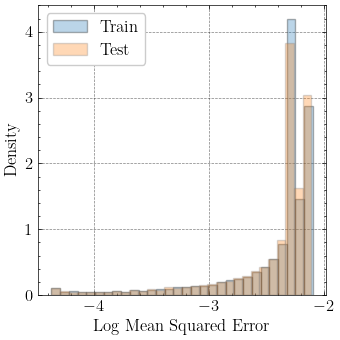

In [126]:
plotting_factor = 1.5
font_factor = 1.5
title_font_size = 10
axes_font_size = 8
plt.rcParams.update({
    "font.size": title_font_size*font_factor,         # Default font size for all text
    "figure.titlesize": title_font_size*font_factor, 
    "axes.labelsize": axes_font_size*font_factor,
    "xtick.labelsize": axes_font_size*font_factor,
    "ytick.labelsize": axes_font_size*font_factor,
    "legend.fontsize": axes_font_size*font_factor,
})


# Compute MSE for train and test
mse_train = np.mean((u_pred - u_ref) ** 2, axis=1)  # axis=0 if columns are different samples
mse_test = np.mean((u_pred_test - u_ref_test) ** 2, axis=1)

# Take the log of MSEs for better visualization
log_mse_train = np.log10(mse_train + 1e-12)  # Add small value to avoid log(0)
log_mse_test = np.log10(mse_test + 1e-12)

# Plot density plot
fig = plt.figure(figsize=(2.5*plotting_factor, plotting_factor*2.5))  # To match your square aspect ratio

bins = 30  # Adjust for resolution of the hist
alpha = 0.3

plt.hist(log_mse_train, bins=bins, density=True, alpha=alpha,
         color='#1f77b4', edgecolor='black', label='Train')
plt.hist(log_mse_test, bins=bins, density=True, alpha=alpha,
         color='#ff7f0e', edgecolor='gray', label='Test')

plt.xlabel("Log Mean Squared Error")
plt.ylabel("Density")
plt.legend()
# plt.grid(False)
plt.tight_layout()
plt.show()
# fig.savefig('figures/PINN-NC_MSE_density.png', format='png', bbox_inches='tight', dpi=300)

In [ ]:
def plot_modes(x_input, model, modes_to_plot, reference_modes=None):

    coeffs =  model.predict(x_input)[0][:,1:]
    coeffs = -coeffs[:, np.argsort(-np.max(np.abs(coeffs), axis=0))]
    # Number of modes to plot
    num_modes = len(modes_to_plot)
    
    # Determine the layout for the subplots: 2 columns if more than 3 modes
    n_cols = num_modes if num_modes <= 3 else num_modes // 2 + num_modes % 2
    n_rows = 1 if num_modes <= 3 else 2
    
    # Create subplots for each mode
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axs = axs.flatten() if num_modes > 1 else [axs]

    for i, mode in enumerate(modes_to_plot):
        ax = axs[i]
        
        ax.plot(x_input[0][0], coeffs[:, mode-1], 'r-', label="PINN-PCE approx.")

        if reference_modes is not None:
            x_ref = np.linspace(-1, 1, len(reference_modes[mode-1,:]))
            ax.plot(x_ref, reference_modes[mode-1,:], 'b--', label="Reference")
            ax.plot(x_sensor, reference_modes[mode-1, sensors_indices], 'ro', label="f sensors")

        ax.set_title(f"Mode {mode}")
        # ax.legend()

    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()
    return fig


# Define the inputs and modes you want to visualize
n_x_plot = 100
subsample_ind = [int(i) for i in np.linspace(0,len(u_std)-1,n_x_plot)]
x_sensor = np.linspace(-1, 1, n_sensors)
sensors_indices = np.linspace(0, len(u_std) - 1, n_sensors, dtype=int)
x_plot = np.linspace(-1, 1, n_x_plot).reshape(-1,1)
x_input = [[x_plot, xi_train]]

modes_to_plot = [1,2,3,4,5,6]
reference_modes = np.load('data/MonteCarlo_PCE_modes_1e6.0.npy')

reference_modes[0,:] = reference_modes[0,:] - np.min(reference_modes[0,:])
sensors_indices = np.linspace(0, reference_modes.shape[1] - 1, n_sensors, dtype=int)

fig = plot_modes(x_input,model, modes_to_plot, reference_modes=reference_modes)
# fig.savefig('figures/PINN_PCE_modes.pdf', format='pdf')

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [ ]:
coeffs =  model.net.apply(model.net.params, x_input[0])[0][:,1:]
coeffs.shape

(100, 8)

In [ ]:
n_x_plot = 100
subsample_ind = [int(i) for i in np.linspace(0,len(u_std)-1,n_x_plot)]
x_sensor = np.linspace(-1, 1, n_sensors)
sensors_indices = np.linspace(0, len(u_std) - 1, n_sensors, dtype=int)
x_input = np.linspace(-1, 1, n_x_plot).reshape(-1,1)
x_input = [x_input, xi_train]

def modes_output(x,output):
    return (output[0] * (1 + x[0]) * (1 - x[0]), output[1])

model.net.apply_output_transform(modes_output)
Y_pred_fun = lambda x: model.net.apply(model.net.params, x)
outputs = Y_pred_fun(x_input)
outputs[0].shape, outputs[1].shape

TypeError: Inputs to MixNN must be a list or tuple, got <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>.